In [1]:
from os import makedirs

import matplotlib.pyplot as plt
import pandas as pd
import statsmodels.api as sm
import statsmodels.formula.api as smf
from pymargins import Margins

OUTPUT_DIR = '02_output'
makedirs(OUTPUT_DIR, exist_ok=True)

df = pd.read_csv('data/enrollments.csv', low_memory=False)

# Clean malformed country names (extra quotes)
df['country'] = df['country'].str.replace('"', '').str.strip()

# Drop rows that are effectively empty header rows (no year value)
df = df.dropna(subset=['year'])

In [2]:
# filter out data prior to 1985 and limit to ME/NA
m_region = df['region'] == 'Middle East and North Africa'
m_after_1985 = df['year'] >= 1985

df = df[m_region & m_after_1985]

In [3]:
# at War on Terrorism indicator
df['wot'] = df['year'] > 2000

# offset year to 0 at 2000
df['year'] -= 2000
# convert to unit steps
df['year'] /= 5

# offset helps make interpretation clearer, and scaling helps convergence

In [4]:
# Count data lends itself well to Poisson regression
# Data is clustered (university), and has a time variable, so GEE is appropriate
fam = sm.families.Poisson()
ind = sm.cov_struct.Exchangeable()
mod = smf.gee("students5_estimated ~ year*wot", "iau_id1", df,
               time=df['year'], cov_struct=ind, family=fam)

fit = mod.fit(maxiter=250)
print(fit.summary())

# WoT positively affected enrollment...
# Time since the start of WoT negatively impacted enrollment (non significant).
# Not what I expected! I expected the opposite
# This is a quick and dirty analysis though.

                               GEE Regression Results                              
Dep. Variable:         students5_estimated   No. Observations:                 5771
Model:                                 GEE   No. clusters:                     1068
Method:                        Generalized   Min. cluster size:                   1
                      Estimating Equations   Max. cluster size:                   8
Family:                            Poisson   Mean cluster size:                 5.4
Dependence structure:         Exchangeable   Num. iterations:                   163
Date:                     Sun, 14 Jun 2026   Scale:                           1.000
Covariance type:                    robust   Time:                         15:20:26
                       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------
Intercept            8.6519      0.133     64.958      0.000       8.391  

/home/hunter/Workspace/cbds-take-home/.venv/lib/python3.14/site-packages/pymargins/margins/_session.py:875: UserWarning: Delta-method curvature κ=0.511 exceeds threshold (0.3, stacklevel=2); falling back to simulation.
  result_data = run_inference(


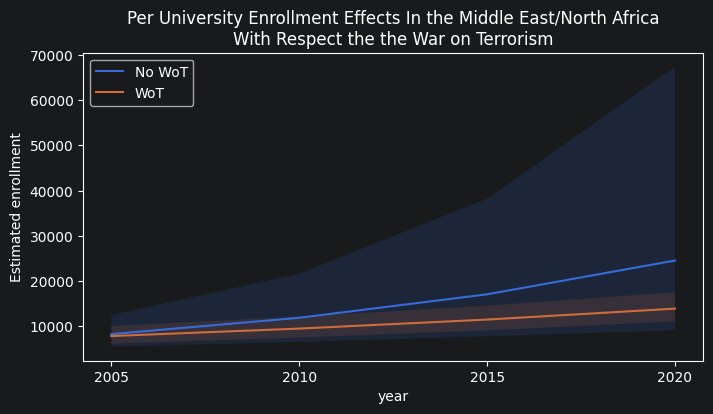

In [5]:
# Estimate WoT Marginal effect on enrollment by year

m = Margins.linear_scale(fit, at="overall")
res = m.predict(atexog={"wot": [0, 1], 'year':[1,2,3,4]})
df_plot = res.to_frame()

fig, ax = plt.subplots(figsize=(8, 4))
for level, sub_df in df_plot.groupby("wot"):
    label = "WoT" if level == 1 else "No WoT"
    ax.plot(sub_df["year"], sub_df["estimate"], label=label)
    ax.fill_between(
        sub_df["year"], sub_df["ci_lower"], sub_df["ci_upper"], alpha=0.15
    )
ax.set_xticks([1, 2, 3, 4])
ax.set_xticklabels(["2005", "2010", "2015", "2020"])
ax.set(xlabel="year", ylabel="Estimated enrollment")
ax.legend()
ax.set_title("Per University Enrollment Effects In the Middle East/North Africa\nWith Respect the the War on Terrorism")
plt.savefig(f'{OUTPUT_DIR}/wot_enrollment_effects.png')
plt.show()

/home/hunter/Workspace/cbds-take-home/.venv/lib/python3.14/site-packages/pymargins/margins/_session.py:1213: UserWarning: Delta-method curvature κ=0.545 exceeds threshold (0.3, stacklevel=2); falling back to simulation.
  result_data = run_inference(


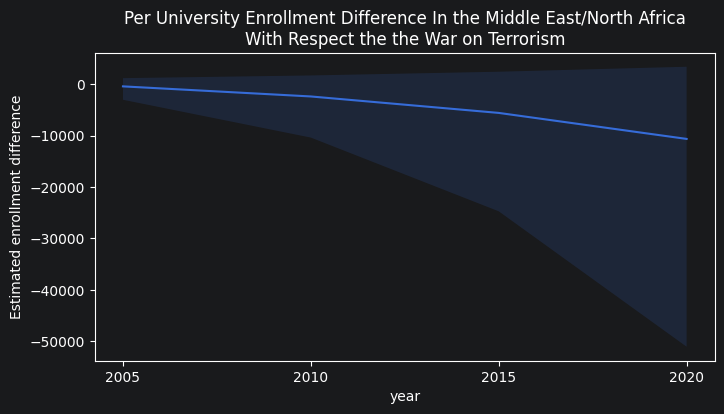

In [6]:
# Estimate WoT Marginal effect contrast (difference) on enrollment by year.
# Difference of the two curves in the previous plot.

scen = []

for i in range(1, 5):
    scen.append({'atexog': {'wot': 1, 'year':i}, 'label': 'wot=1'})
    scen.append({'atexog': {'wot': 0, 'year':i}, 'label': 'wot=0'})

w = []

for i in range(1, 5):
    x = 8 * [0]
    x[(i - 1) * 2] = 1
    x[(i - 1) * 2 + 1] = -1
    w.append(x)

res = m.contrasts(scenarios=scen, contrasts=w)

df_plot = res.to_frame()

fig, ax = plt.subplots(figsize=(8, 4))

ax.plot(df_plot.index, df_plot["estimate"])
ax.fill_between(
    df_plot.index, df_plot["ci_lower"], df_plot["ci_upper"], alpha=0.15
)
ax.set(xlabel="year", ylabel="Estimated enrollment difference")
ax.set_xticks([0, 1, 2, 3])
ax.set_xticklabels(["2005", "2010", "2015", "2020"])
ax.set_title("Per University Enrollment Difference In the Middle East/North Africa\nWith Respect the the War on Terrorism")
plt.savefig(f'{OUTPUT_DIR}/wot_enrollment_contrast.png')
plt.show()